In [ ]:
import numpy as np
import os, cv2, pickle
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
IMAGE_DIR = os.path.join(path, "cell_images", "cell_images")
print("Classes:", os.listdir(IMAGE_DIR))

100%|██████████| 675M/675M [00:33<00:00, 21.0MB/s]

Extracting files...


Classes: ['Uninfected', 'Parasitized']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
import pickle

model = load_model('/content/drive/MyDrive/malaria_project/best_final.keras')
print("✓ Model loaded!")

with open('/content/drive/MyDrive/malaria_project/training_history.pkl', 'rb') as f:
    combined_history = pickle.load(f)

history1_hist = combined_history['phase1']
history2_hist = combined_history.get('phase2', None)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Model loaded!


In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
SEED       = 42

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=IMG_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    IMAGE_DIR,
    target_size=IMG_SIZE,
    class_mode='binary',
    batch_size=BATCH_SIZE,
    subset='validation',S
    seed=SEED,
    shuffle=False
)

print("Class indices:", train_gen.class_indices)


Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
Class indices: {'Parasitized': 0, 'Uninfected': 1}


Train Input  batch Shape: (64, 128, 128, 3)
Train Output batch Shape: (64,)


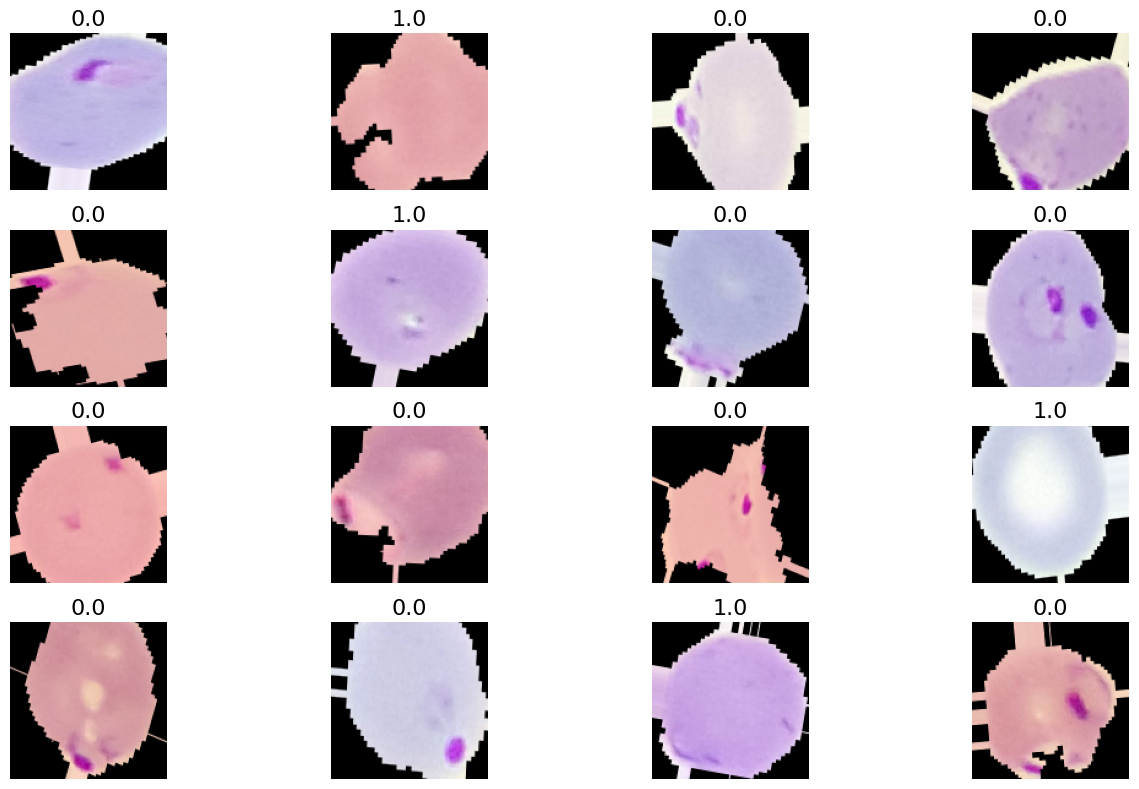

In [ ]:
# ── DATA VISUALIZATION ───────────────────────────────────────
X_batch, Y_batch = next(train_gen)
print("Train Input  batch Shape:", X_batch.shape)
print("Train Output batch Shape:", Y_batch.shape)

fig = plt.figure(figsize=(14, 8))
for i in range(16):
    ax = fig.add_subplot(4, 4, i+1)
    # preprocess_input shifts values — rescale back to [0,1] for display
    img_display = X_batch[i] - X_batch[i].min()
    img_display = img_display / img_display.max()
    ax.imshow(img_display)
    ax.set_title(str(Y_batch[i]), fontsize=16)
    ax.axis(False)
plt.tight_layout()
plt.show()

In [ ]:
# Clear session and rebuild model fresh
tf.keras.backend.clear_session()

In [ ]:
tf.keras.backend.clear_session()

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Reset generators
train_gen.reset()
val_gen.reset()


In [ ]:
# ── CLASS WEIGHT (add this before model.fit) ──────────────
import os

parasitized_count = len([f for f in os.listdir(os.path.join(IMAGE_DIR, 'Parasitized'))
                         if not f.startswith('.')])
uninfected_count  = len([f for f in os.listdir(os.path.join(IMAGE_DIR, 'Uninfected'))
                         if not f.startswith('.')])
total = parasitized_count + uninfected_count

class_weight = {
    0: total / (2 * parasitized_count),
    1: total / (2 * uninfected_count)
}

print(f"Parasitized: {parasitized_count}, Uninfected: {uninfected_count}")
print(f"Class weights: {class_weight}")

Parasitized: 13780, Uninfected: 13780
Class weights: {0: 1.0, 1: 1.0}


In [ ]:
print("\n=== PHASE 1: Training head only ===")

callbacks_p1 = [
    EarlyStopping(monitor='val_auc', patience=6,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3,                   # was 2
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_phase1.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1)
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_p1,
    class_weight=class_weight
)



=== PHASE 1: Training head only ===
Epoch 1/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8458 - auc: 0.9196 - loss: 0.3469
Epoch 1: val_auc improved from None to 0.97001, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
345/345 ━━━━━━━━━━━━━━━━━━━━ 196s 477ms/step - accuracy: 0.8852 - auc: 0.9521 - loss: 0.2800 - val_accuracy: 0.8946 - val_auc: 0.9700 - val_loss: 0.2458 - learning_rate: 0.0010
Epoch 2/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9083 - auc: 0.9659 - loss: 0.2344
Epoch 2: val_auc improved from 0.97001 to 0.97283, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
345/345 ━━━━━━━━━━━━━━━━━━━━ 127s 368ms/step - accuracy: 0.9096 - auc: 0.9664 - loss: 0.2328 - val_accuracy: 0.9078 - val_auc: 0.9728 - val_loss: 0.2186 - learning_rate: 0.0010
Epoch 3/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9149 - auc: 0.9691 - loss: 0.2234
Epoch 3: val_auc improved from

In [ ]:
print("\n=== PHASE 2: Fine-tuning ===")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very small LR
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_p2 = [
    EarlyStopping(monitor='val_auc', patience=6,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_final.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_p2,
    class_weight=class_weight
)


=== PHASE 2: Fine-tuning ===
Epoch 1/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8910 - auc: 0.9524 - loss: 0.3245
Epoch 1: val_auc improved from None to 0.95125, saving model to best_final.keras

Epoch 1: finished saving model to best_final.keras
345/345 ━━━━━━━━━━━━━━━━━━━━ 196s 451ms/step - accuracy: 0.8997 - auc: 0.9581 - loss: 0.2951 - val_accuracy: 0.8849 - val_auc: 0.9512 - val_loss: 0.2938 - learning_rate: 1.0000e-05
Epoch 2/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9064 - auc: 0.9625 - loss: 0.2712
Epoch 2: val_auc improved from 0.95125 to 0.95659, saving model to best_final.keras

Epoch 2: finished saving model to best_final.keras
345/345 ━━━━━━━━━━━━━━━━━━━━ 129s 373ms/step - accuracy: 0.9067 - auc: 0.9642 - loss: 0.2600 - val_accuracy: 0.8922 - val_auc: 0.9566 - val_loss: 0.2710 - learning_rate: 1.0000e-05
Epoch 3/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9125 - auc: 0.9685 - loss: 0.2354
Epoch 3: val_auc improved from 0.

In [ ]:
import os, shutil, pickle
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/malaria_project/'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Save model
model.save(DRIVE_PATH + 'malaria_model.keras')
print("✓ malaria_model.keras saved")

# Save history (only phase1 if phase2 errored)
try:
    combined_history = {'phase1': history1.history, 'phase2': history2.history}
except:
    combined_history = {'phase1': history1.history}

with open(DRIVE_PATH + 'training_history.pkl', 'wb') as f:
    pickle.dump(combined_history, f)
print("✓ training_history.pkl saved")

# Copy checkpoint files
for f in ['best_phase1.keras', 'best_final.keras']:
    if os.path.exists(f):
        shutil.copy(f, DRIVE_PATH + f)
        print(f"✓ {f} saved")

print("\nAll files saved to Drive!")

Mounted at /content/drive
✓ malaria_model.keras saved
✓ training_history.pkl saved
✓ best_phase1.keras saved
✓ best_final.keras saved

All files saved to Drive!


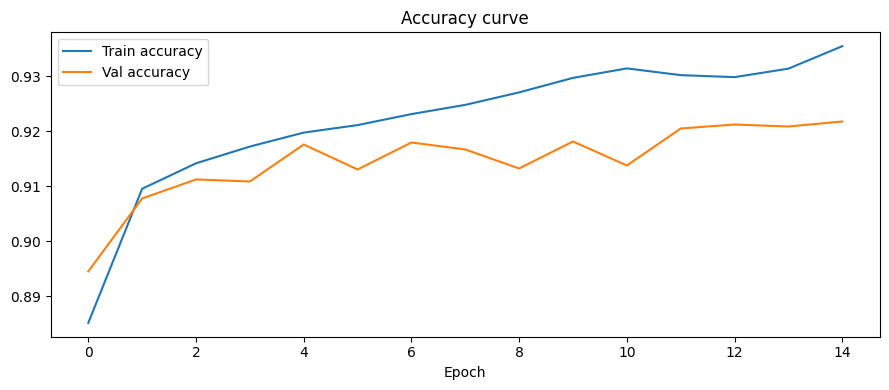

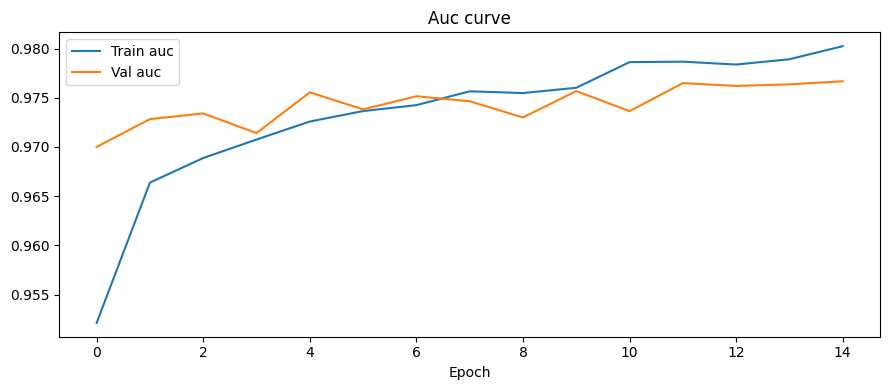

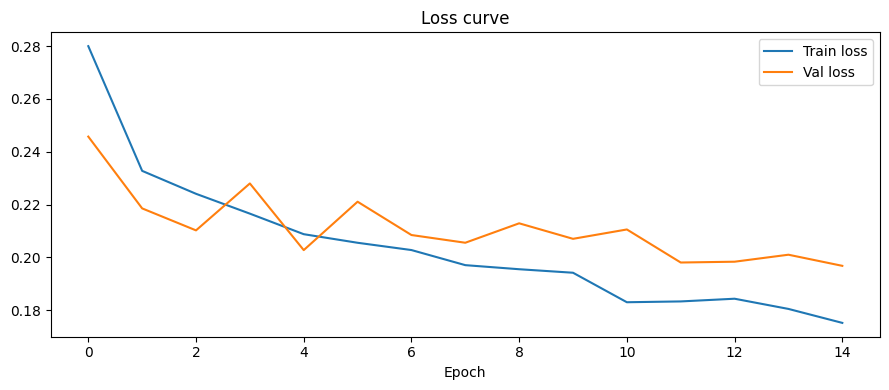

In [ ]:
def plot_single(h, metric):

    data = h.history if hasattr(h, 'history') else h

    plt.figure(figsize=(9, 4))
    plt.plot(data[metric], label=f'Train {metric}')
    plt.plot(data[f'val_{metric}'], label=f'Val {metric}')
    plt.title(f'{metric.capitalize()} curve')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'curve_{metric}.png', dpi=150)
    plt.show()

# Now call with the loaded dict
plot_single(combined_history['phase1'], 'accuracy')
plot_single(combined_history['phase1'], 'auc')
plot_single(combined_history['phase1'], 'loss')

87/87 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.94      0.89      0.92      2755
  Uninfected       0.89      0.95      0.92      2755

    accuracy                           0.92      5510
   macro avg       0.92      0.92      0.92      5510
weighted avg       0.92      0.92      0.92      5510



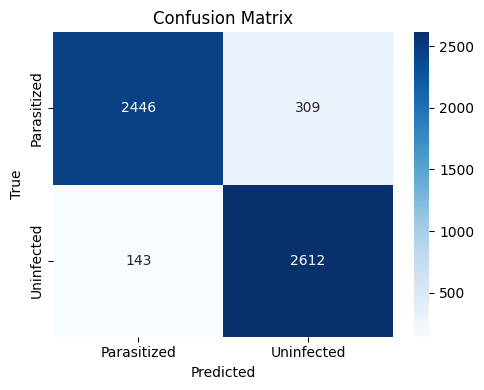

In [ ]:
val_gen.reset()
y_prob = model.predict(val_gen, verbose=1)
y_pred = (y_prob > 0.5).astype(int).flatten()
y_true = val_gen.classes

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=list(val_gen.class_indices.keys())
))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_gen.class_indices.keys(),
            yticklabels=val_gen.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
LAST_CONV = 'top_activation'  # EfficientNetB0 last conv layer

def gradcam_heatmap(img_array, model, last_conv):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads       = tape.gradient(loss, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap     = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(img_path, model, ax_row):
    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(cv2.resize(img, IMG_SIZE), cv2.COLOR_BGR2RGB)
    inp     = np.expand_dims(preprocess_input(img_rgb.astype(np.float32)), 0)

    pred    = model.predict(inp, verbose=0)[0][0]
    label   = "Uninfected" if pred > 0.5 else "Parasitized"
    conf    = pred if pred > 0.5 else 1 - pred

    heatmap = gradcam_heatmap(inp, model, LAST_CONV)
    heat_up = cv2.resize(heatmap, IMG_SIZE)
    colored = cv2.applyColorMap(np.uint8(255 * heat_up), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_rgb, 0.6, colored, 0.4, 0)

    ax_row[0].imshow(img_rgb);          ax_row[0].axis('off')
    ax_row[1].imshow(heatmap, cmap='jet'); ax_row[1].axis('off'); ax_row[1].set_title('Heatmap')
    ax_row[2].imshow(overlay);          ax_row[2].axis('off'); ax_row[2].set_title(f'{label} ({conf:.1%})')


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


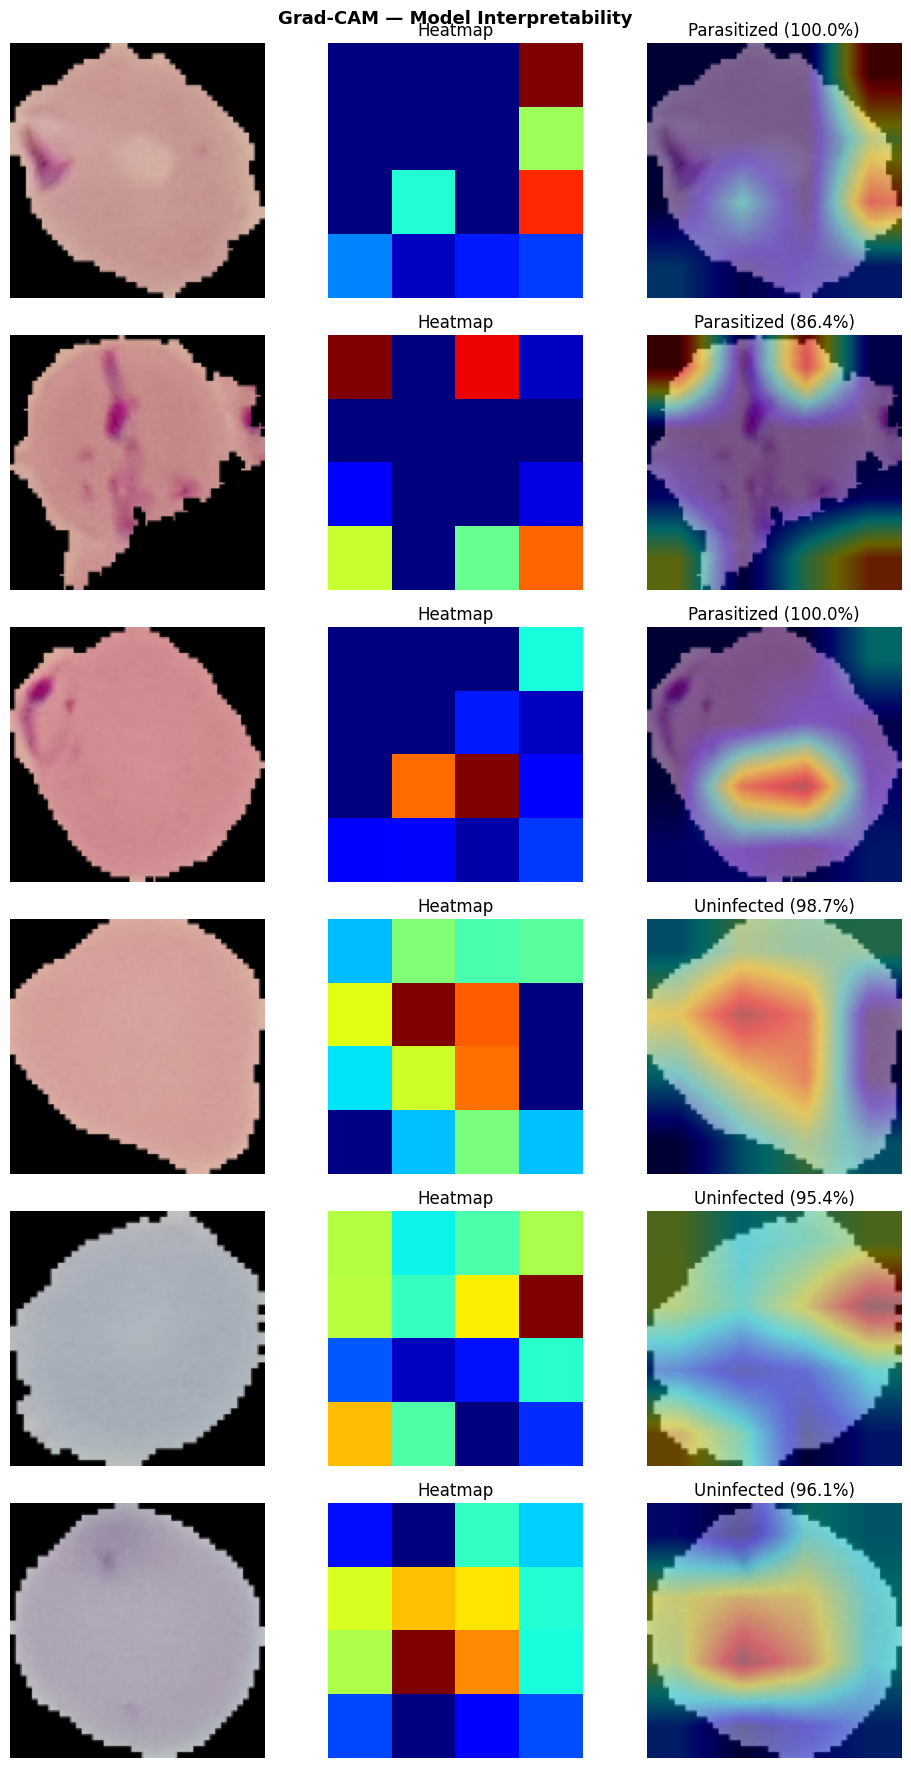

Grad-CAM saved: gradcam.png


In [ ]:
classes   = ['Parasitized', 'Uninfected']
fig, axes = plt.subplots(6, 3, figsize=(10, 18))
fig.suptitle('Grad-CAM — Model Interpretability', fontsize=13, fontweight='bold')

row = 0
for cls in classes:
    cls_dir = os.path.join(IMAGE_DIR, cls)
    files   = [f for f in os.listdir(cls_dir) if not f.startswith('.')][:3]
    for fname in files:
        axes[row][0].set_ylabel(cls, fontsize=9)
        show_gradcam(os.path.join(cls_dir, fname), model, axes[row])
        row += 1

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM saved: gradcam.png")


In [ ]:
print("\n✓ malaria_model.keras")
print("✓ training_history.pkl")
print("✓ best_phase1.keras")
print("✓ best_final.keras")
print("✓ confusion_matrix.png")
print("✓ gradcam.png")



✓ malaria_model.keras
✓ training_history.pkl
✓ best_phase1.keras
✓ best_final.keras
✓ confusion_matrix.png
✓ gradcam.png
